In [20]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler,LabelEncoder,OneHotEncoder,OrdinalEncoder
import matplotlib.pyplot as plt
import pickle
import warnings
warnings.filterwarnings('ignore')

In [21]:
df = pd.read_csv("Mall_Customers.csv")

In [22]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [35]:
df.shape


(200, 5)

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [34]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [36]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [37]:
df.duplicated().sum()

np.int64(0)

No missing values and no duplicate rows found.

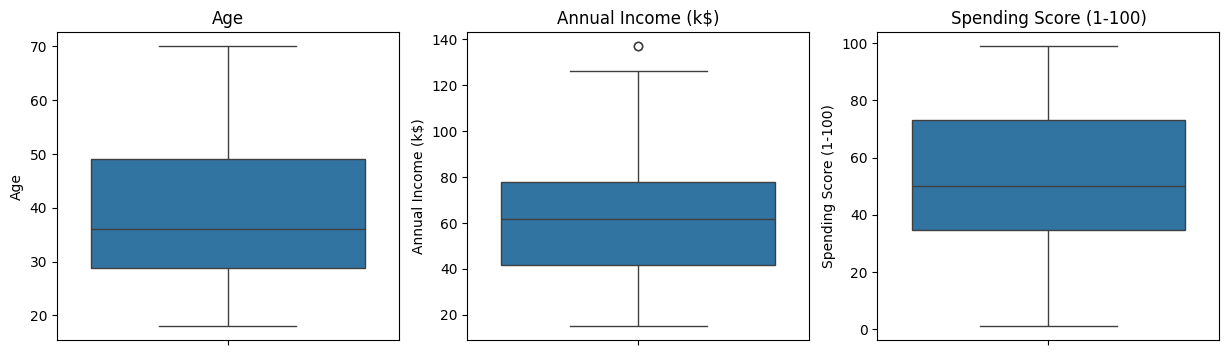

In [39]:
plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
sns.boxplot(y=df["Age"])
plt.title("Age")

plt.subplot(1,3,2)
sns.boxplot(y=df["Annual Income (k$)"])
plt.title("Annual Income (k$)")

plt.subplot(1,3,3)
sns.boxplot(y=df["Spending Score (1-100)"])
plt.title("Spending Score (1-100)")

plt.show()

In [40]:
Q1 = df["Annual Income (k$)"].quantile(0.25)
Q3 = df["Annual Income (k$)"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df[(df["Annual Income (k$)"] < lower_bound) | (df["Annual Income (k$)"] > upper_bound)]

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
198,199,Male,32,137,18
199,200,Male,30,137,83


These two rows aren't errors, just genuinely high earners (137k each). Keeping them as is.

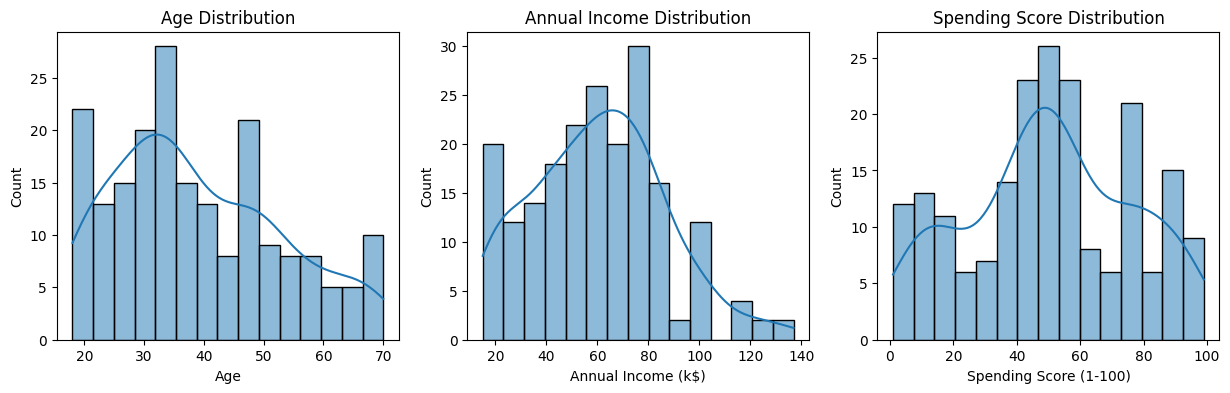

In [54]:
plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
sns.histplot(df["Age"], kde=True, bins=15)
plt.title("Age Distribution")

plt.subplot(1,3,2)
sns.histplot(df["Annual Income (k$)"], kde=True, bins=15)
plt.title("Annual Income Distribution")

plt.subplot(1,3,3)
sns.histplot(df["Spending Score (1-100)"], kde=True, bins=15)
plt.title("Spending Score Distribution")

plt.show()

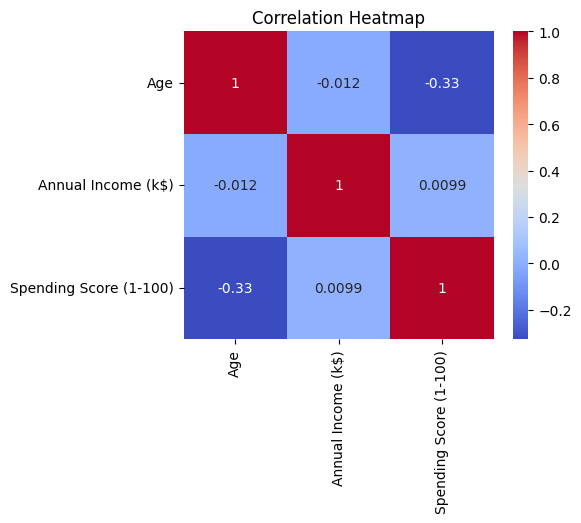

In [42]:
plt.figure(figsize=(5,4))
sns.heatmap(df[["Age","Annual Income (k$)","Spending Score (1-100)"]].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

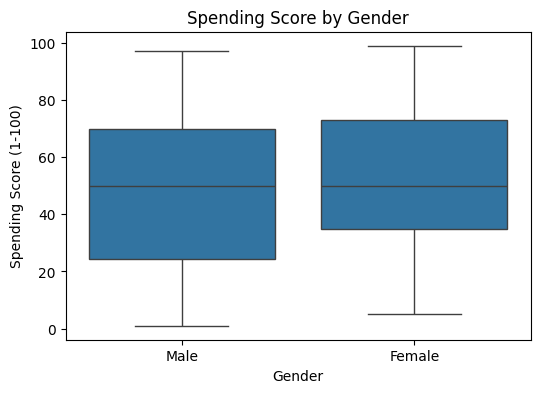

In [43]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Gender", y="Spending Score (1-100)", data=df)
plt.title("Spending Score by Gender")
plt.show()

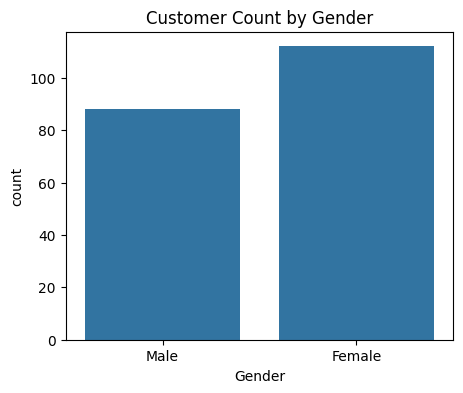

In [44]:
plt.figure(figsize=(5,4))
sns.countplot(x="Gender", data=df)
plt.title("Customer Count by Gender")
plt.show()

In [50]:
df = df.drop("CustomerID", axis=1)
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


In [51]:
bins = [17, 25, 35, 45, 55, 71]
labels = ["18-25", "26-35", "36-45", "46-55", "56-70"]

df["Age_Group"] = pd.cut(df["Age"], bins=bins, labels=labels)
df[["Age", "Age_Group"]].head(10)

,Age,Age_Group
0,19,18-25
1,21,18-25
2,20,18-25
3,23,18-25
4,31,26-35
5,22,18-25
6,35,26-35
7,23,18-25
8,64,56-70
9,30,26-35


In [52]:
df["Spending_to_Income_Ratio"] = (df["Spending Score (1-100)"] / df["Annual Income (k$)"]).round(2)
df[["Annual Income (k$)", "Spending Score (1-100)", "Spending_to_Income_Ratio"]].head(10)

,Annual Income (k$),Spending Score (1-100),Spending_to_Income_Ratio
0,15,39,2.60
1,15,81,5.40
2,16,6,0.38
3,16,77,4.81
4,17,40,2.35
5,17,76,4.47
6,18,6,0.33
7,18,94,5.22
8,19,3,0.16
9,19,72,3.79


Key Insights



1.  The dataset was already clean going in, no missing values and no duplicate rows, so there wasn't much cleanup needed.

2.  Two customers earning 137k got flagged as outliers. I checked them manually and they looked fine (normal age, normal spending pattern), so I decided to keep them instead of removing them.

1.   Age and spending score have a weak negative relationship (around -0.33). Older customers spend a little less on average, but it's not a huge effect.

2.   Income and spending score barely correlate at all (close to 0). That was kind of surprising, having more income doesn't really mean someone spends more. This is probably why this dataset is used a lot for customer segmentation, since people don't just split into "low spenders" and "high spenders" based on income alone.



1.   Gender didn't make much difference either. There are more female customers in the data (112 vs 88), but their median spending score is basically the same as male customers.






